<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/2026.05/Lab4_PE_keithley_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect

v0.2.1 Automated measurements. Diodes

v0.2.2 Lamp + Filters

In [9]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c

In [10]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

#Volt-ampere curve


In [11]:
def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            if -2 < root < 0: # only voltages in -2 .. 0 V
               roots.append(root)
    return roots[0]


# Dark current

In [12]:
# Calculated from ambient light data
dark_min = -158e-12 #A
dark_max = -204e-12


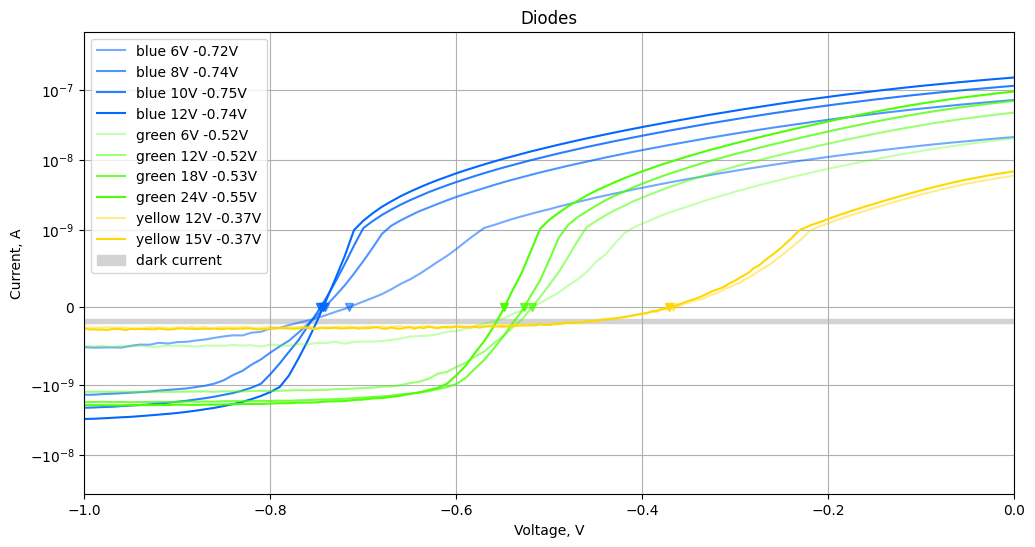

In [13]:
names = ['blue', 'green', 'yellow']
waves = [456, 525, 592]
n = len(names)


fig, ax = plt.subplots(1, 1, figsize=(12,6))
plt.grid()

data = '# color wavelength power V0\n'


for i, name in enumerate(names):
  color= wavelength_to_color(waves[i])
  url = f'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.05/{name}.csv'
  txt = requests.get(url).text
  LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(txt.splitlines(), \
                                                    delimiter=',', skip_header=1, unpack=True)

  powers = np.unique(LED_V)

  for power in powers:
    if power == np.min(powers):
      continue
    if power == 1:
      continue
    mask = (LED_V == power)
    V = V_set[mask]
    I = I_avg_A[mask]
    opacity = 0.1 + 0.89 * (power - np.min(powers)) / (np.max(powers) - np.min(powers))

    # Find points where current I crosses zero current line
    V0 = find_roots(V, I)
    plt.plot(V0, 0, color=color, alpha = opacity, marker='v')
    data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # zero\n'

    # Find points where current I crosses dark current band
    #V0 = find_roots(V, I - dark_min)
    #plt.plot(V0, dark_min, color=color, alpha = opacity, marker='v')
    #ata += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # left\n'

    #V0 = find_roots(V, I - dark_max)
    #plt.plot(V0, dark_max, color=color, alpha = opacity, marker='^')
    #data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # right\n'


    plt.plot(V, I, color=color, alpha=opacity, label=f'{name} {power:.0f}V {V0:.2f}V')


plt.fill_between(V, dark_min, dark_max, color='lightgray', label='dark current')
plt.legend()
plt.xlim(-1, 0)

#plt.ylim(-250e-12, -100e-12)

plt.xlabel('Voltage, V')
plt.ylabel('Current, A')
plt.yscale('symlog', linthresh=1e-9)
plt.title('Diodes')
plt.show()


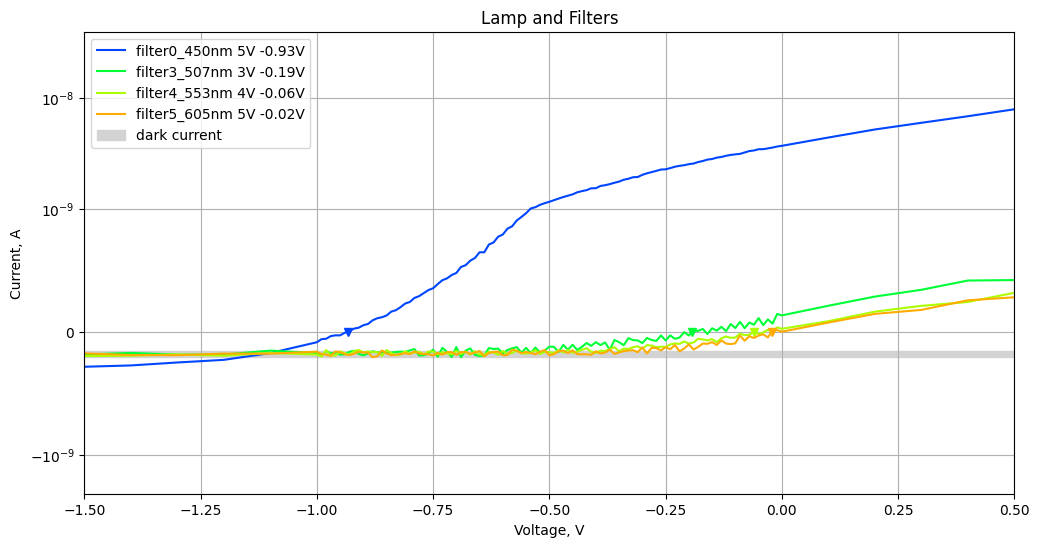

In [14]:
names = ['blue', 'green', 'yellow']
waves = [456, 525, 592]
n = len(names)

names += ['filter0_450nm', 'filter3_507nm', 'filter4_553nm', 'filter5_605nm']
waves += [450, 507, 553, 605]






fig, ax = plt.subplots(1, 1, figsize=(12,6))
plt.grid()


for i, name in enumerate(names):
  if i < n:
    continue
  color= wavelength_to_color(waves[i])
  url = f'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.05/{name}.csv'
  txt = requests.get(url).text
  LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(txt.splitlines(), \
                                                    delimiter=',', skip_header=1, unpack=True)

  powers = np.unique(LED_V)

  for power in powers:
    #if power != 5:
    #  continue
    mask = (LED_V == power)
    V = V_set[mask]
    I = I_avg_A[mask]
    opacity = 1

    # Find points where current I crosses zero current line
    V0 = find_roots(V, I)
    plt.plot(V0, 0, color=color, alpha = opacity, marker='v')
    data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # zero\n'

    # Find points where current I crosses dark current band
    #V0 = find_roots(V, I - dark_min)
    #plt.plot(V0, dark_min, color=color, alpha = opacity, marker='v')
    #ata += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # left\n'

    #V0 = find_roots(V, I - dark_max)
    #plt.plot(V0, dark_max, color=color, alpha = opacity, marker='^')
    #data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # right\n'


    plt.plot(V, I, color=color, alpha=opacity, label=f'{name} {power:.0f}V {V0:.2f}V')


plt.fill_between(V, dark_min, dark_max, color='lightgray', label='dark current')
plt.legend()
plt.xlim(-1.5, 0.5)

#plt.ylim(-250e-12, -100e-12)

plt.xlabel('Voltage, V')
plt.ylabel('Current, A')
plt.yscale('symlog', linthresh=1e-9)
plt.title('Lamp and Filters')
plt.show()


In [15]:
print(data)

# color wavelength power V0
0 456 6 0.715 # zero
0 456 8 0.741 # zero
0 456 10 0.746 # zero
0 456 12 0.743 # zero
1 525 6 0.519 # zero
1 525 12 0.519 # zero
1 525 18 0.527 # zero
1 525 24 0.548 # zero
2 592 12 0.367 # zero
2 592 15 0.371 # zero
3 450 5 0.933 # zero
4 507 3 0.192 # zero
5 553 4 0.060 # zero
6 605 5 0.021 # zero



# Plank's constant and Work potential determination

$$
 e V_0(\nu) = h \nu -  e W
$$

/tmp/ipykernel_1644/2656105328.py:5: RuntimeWarning: divide by zero encountered in divide
  return c / wl


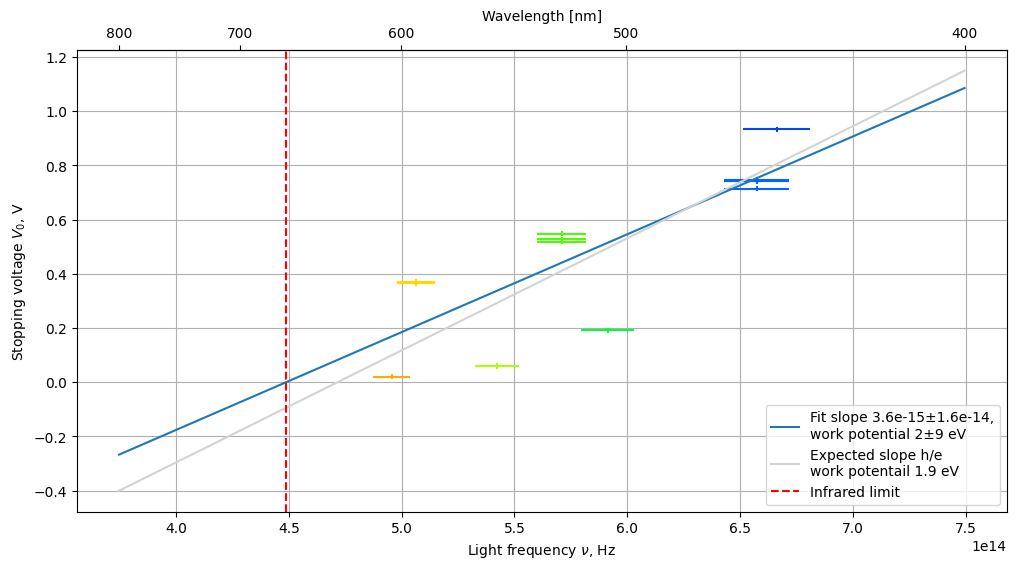

In [18]:
def linear(nu, slope, offset):
    return slope * nu - offset

def wl2freq(wl):
    return c / wl


def freq2wl(nu):
    return c / nu * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(freq2wl, wl2freq))
secax.set_xlabel('Wavelength [nm]')


ix, wl, power, V0 = np.genfromtxt(data.splitlines()).T


relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
V_err = 0.01 # V
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset
popt, pcov = curve_fit(linear, nu , V0)
slope = popt[0]
offset = popt[1]

# errors in coeffs of linear regression, as in Taylor Ch8.
y = V0
x = nu
N = len(y)
sigma2_y = np.sum( (y - offset - slope * x)**2) / (N - 2)
Delta = N * np.sum(x**2) - np.sum(x)**2
offset_err = np.sqrt(sigma2_y * np.sum(x**2) / Delta)
slope_err = np.sqrt(N * sigma2_y / Delta)

offset_expected = 1.95 # V, for Cs-Sb Photocathode
for i in range(len(V0)):
  ind = int(ix[i])
  plt.errorbar(nu[i], V0[i], yerr=V_err, xerr=nu_err[i], ls='', color=wavelength_to_color(wl[i]*1e9))

wl_dense = np.linspace(400, 800)  * 1e-9
nu_dense = c / wl_dense

plt.plot(nu_dense, linear(nu_dense, slope, offset), label=f'Fit slope {slope:.1e}±{slope_err:.1e},\nwork potential {offset:.0f}±{offset_err:.0f} eV')
plt.plot(nu_dense, linear(nu_dense, h/e, offset_expected) , color='lightgray', label=f'Expected slope h/e\nwork potentail {offset_expected:.1f} eV')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light frequency $\nu$, Hz')
plt.ylabel(r'Stopping voltage $V_0$, V')
Infrared_PhotoEmission_limit = offset / slope
plt.axvline(Infrared_PhotoEmission_limit, color='red', ls='--', label='Infrared limit')
plt.legend()
plt.show()
#plt.xlim(0.2, 1)
plt.show()

